Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=124585844949264 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=129,137,667 params_trainable=129,137,667


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,1.985800,0.637274,0.736667,0.731283,0.733780,0.736667,0.124561,37.368287
2,1.137100,0.543480,0.786667,0.787808,0.790359,0.786667,0.106273,31.881809
3,0.966800,0.486541,0.803333,0.804487,0.807977,0.803333,0.095765,28.729518
4,0.810700,0.449521,0.816667,0.817822,0.822175,0.816667,0.088700,26.610028
5,0.746600,0.429593,0.820000,0.821884,0.826150,0.820000,0.083932,25.179735
6,0.635700,0.415166,0.826667,0.828254,0.831621,0.826667,0.080999,24.299787
7,0.576800,0.413320,0.823333,0.825096,0.829085,0.823333,0.080649,24.194612


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=30.79s tok/s=0.0 ex/s=0.00 peak_mem=2.98GiB lr=9.13e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.61s tok/s=135328.1 ex/s=1057.25
[EVALUATION_PERFORMANCE] accuracy=0.7367 cost=$0.02 accuracy_per_$=40.88
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=9.127789046653144e-06 id=124585844949264 hyperparams={'lr': 9.127789046653144e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 9.127789046653144e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[9.127789046653144e-06]
[PARAMS]   pa

[EVALUATION_PERFORMANCE] tokens=81920 time=0.87s tok/s=93625.2 ex/s=731.45
[EVALUATION_PERFORMANCE] accuracy=0.8467 cost=$0.18 accuracy_per_$=4.67

### STATE-SPACES/MAMBA-130M-HF EVALUATION METRICS ###
{'epoch': 7.0,
 'eval_accuracy': 0.8466666666666667,
 'eval_f1_macro': 0.8457290268235541,
 'eval_loss': 0.41392216086387634,
 'eval_mse': 0.0789388911140891,
 'eval_precision_macro': 0.8480553673344863,
 'eval_recall_macro': 0.8466666666666667,
 'eval_runtime': 0.9591,
 'eval_samples_per_second': 312.807,
 'eval_sse': 23.681667334226727,
 'eval_steps_per_second': 5.213}


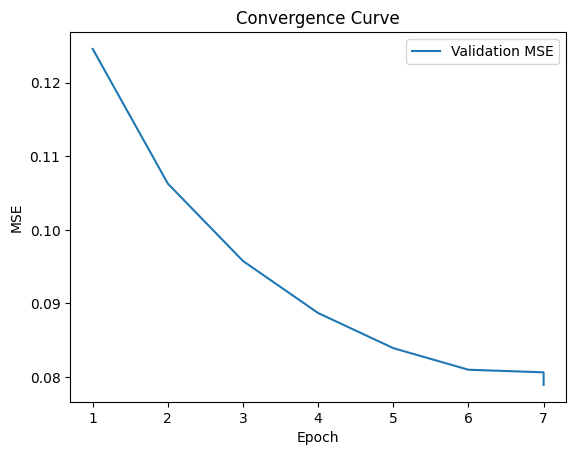

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mamba_context = context.setup_pipeline(Mamba, require_translation = False)
    mamba_trainer = sentiment.train(mamba_context)

